# PCA Demo

Now we're going to use PCA to explore the same dataset.

First we read it in...

In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv('../../datasets/foodsAndMovies.csv.gz')
foodFrame = df[['Broccoli', 'Mushrooms', 'Beef Tacos', 'Salads', 'Black Licorice', 'Steak', 'Grilled Chicken', 'Mayonnaise', 'Candy Corn', 'Pulled Pork', 'Spicy Mustard', 'Raw Oysters', 'Bananas', 'Avocado', 'Eggs', 'Olives', 'Tofu', 'Cottage Cheese']]
foodFrame.head()

,Broccoli,Mushrooms,Beef Tacos,Salads,Black Licorice,Steak,Grilled Chicken,Mayonnaise,Candy Corn,Pulled Pork,Spicy Mustard,Raw Oysters,Bananas,Avocado,Eggs,Olives,Tofu,Cottage Cheese
0,4.0,4.0,5.0,3.0,NaN,5.0,4.0,4.0,1.0,5.0,5.0,4.0,4.0,4.0,4.0,4.0,2.0,2.0
1,2.0,1.0,4.0,2.0,1.0,5.0,4.0,3.0,3.0,4.0,3.0,2.0,4.0,3.0,5.0,2.0,4.0,3.0
2,4.0,2.0,5.0,4.0,3.0,5.0,5.0,1.0,3.0,4.0,NaN,NaN,2.0,NaN,5.0,NaN,NaN,NaN
3,4.0,4.0,4.0,4.0,1.0,4.0,4.0,4.0,1.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,2.0
4,4.0,3.0,5.0,4.0,4.0,5.0,4.0,2.0,1.0,5.0,4.0,2.0,2.0,3.0,5.0,3.0,2.0,1.0


Fill in the NaNs with the means...

In [2]:
foodFrame.fillna(foodFrame.mean(),inplace=True)
foodFrame.head()

/tmp/ipykernel_789500/3753614993.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  foodFrame.fillna(foodFrame.mean(),inplace=True)


,Broccoli,Mushrooms,Beef Tacos,Salads,Black Licorice,Steak,Grilled Chicken,Mayonnaise,Candy Corn,Pulled Pork,Spicy Mustard,Raw Oysters,Bananas,Avocado,Eggs,Olives,Tofu,Cottage Cheese
0,4.0,4.0,5.0,3.0,1.752613,5.0,4.0,4.0,1.0,5.0,5.000000,4.000000,4.0,4.000000,4.0,4.00000,2.0000,2.000000
1,2.0,1.0,4.0,2.0,1.000000,5.0,4.0,3.0,3.0,4.0,3.000000,2.000000,4.0,3.000000,5.0,2.00000,4.0000,3.000000
2,4.0,2.0,5.0,4.0,3.000000,5.0,5.0,1.0,3.0,4.0,2.994881,2.608133,2.0,3.900506,5.0,2.69863,2.4631,2.358423
3,4.0,4.0,4.0,4.0,1.000000,4.0,4.0,4.0,1.0,4.0,4.000000,4.000000,4.0,4.000000,4.0,2.00000,4.0000,2.000000
4,4.0,3.0,5.0,4.0,4.000000,5.0,4.0,2.0,1.0,5.0,4.000000,2.000000,2.0,3.000000,5.0,3.00000,2.0000,1.000000


OK, so now I'm going to take the PCA using sklearn.  I'm going to go ahead and use all the dimensions, just to extract some information about the structure of the data.

In [3]:
from sklearn.decomposition import PCA
pca=PCA(n_components=18)
pca.fit(foodFrame)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",18
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

sklearn will tell me what percentage of the variance is explained by each of these principal components.  Naturally, since the first one is most important, the second the most important, etc., we expect these numbers to be decreasing.

In [4]:
pca.explained_variance_ratio_

array([0.19976644, 0.09489867, 0.07940548, 0.06544091, 0.06222292,
       0.05795761, 0.05621931, 0.05030453, 0.04909805, 0.04396177,
       0.04109439, 0.03773113, 0.03684429, 0.0305426 , 0.02783591,
       0.02708628, 0.02228071, 0.01730899])

Indeed they are.  It looks like the first principal component explains about 20% of the variability, the second explains about 9%, and so on.  Let's plot these.  In addition, let's plot the total variability explained by a component or earlier - meaning, what variability is explained in total by the first component, then the first two components together, then the first three components together, etc.

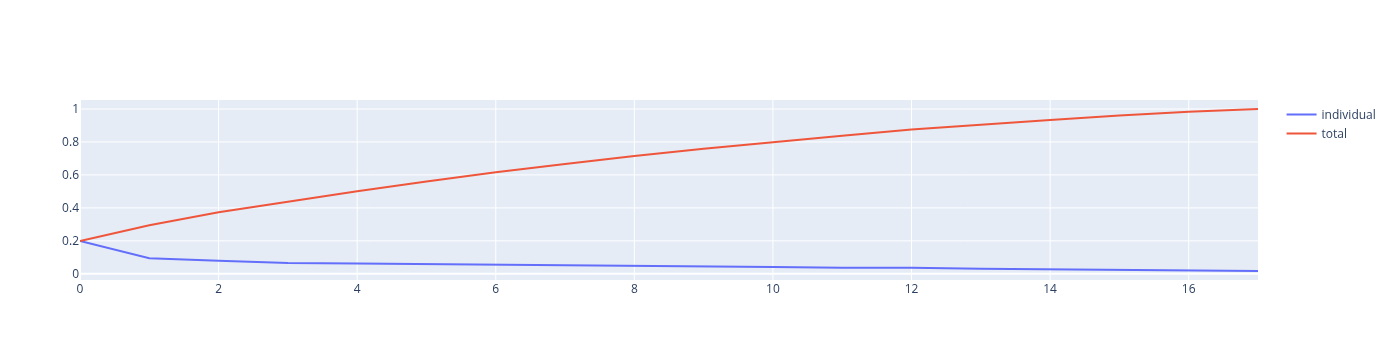

In [5]:
import plotly.graph_objects as go
trace1=go.Scatter(y=pca.explained_variance_ratio_,mode='lines',name='individual')
totalexplained=[sum(pca.explained_variance_ratio_[:i]) for i in range(1,19)]
trace2=go.Scatter(y=totalexplained,mode='lines',name='total')
fig=go.Figure(data=[trace1,trace2])
fig.show()

So the blue line is each individual principal component's variability ratio, and the red is the total up to that component.

This is actually a little disheartening, and suggests that we can't do much dimensionality reduction here.  Right now, our data exists in 18 dimensional space.  If we're willing to throw away half the variability, we can do that with only 4 dimensions.  If we want to keep 80%, we have to keep 10 dimensions.  This is less structure than many datasets; we've learned that there is considerable (though not total) independence between how much people like different foods.

Let's look at the first principal component, and see what we can learn.

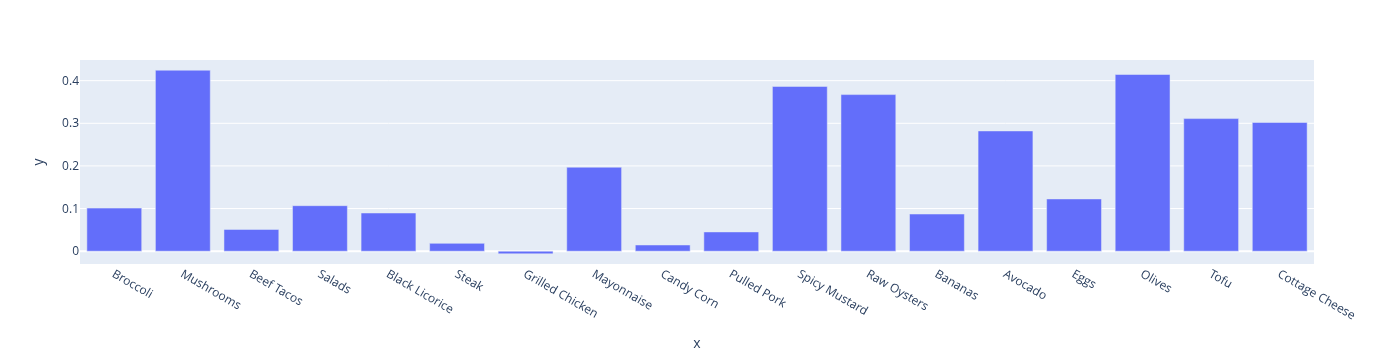

In [6]:
import plotly.express as px
fig=px.bar(x=foodFrame.columns,y=pca.components_[0,:])
fig.show()

So, what on earth does this mean?  The first component is a direction in our original 18-dimensional space, along which there is maximal variability.  That means this one line describes the direction of maximum change for data in the dataset.

In this case, (but for grilled chicken) all of the 18 values are the same sign.  This means that, as a person's enjoyment of mushrooms increases, we expect their stated enjoyment of every other food to increase as well.  As their enjoyment decreases, we expect their stated enjoyment of every other food to decrease as well.  This is particularly true for mushrooms, spicy mustard, raw oysters, and olives, and less true for steak, candy corn, grilled chicken, all of which show little change.

In other words, the first principal component primarily captures how much do people like food.

## Visualization

We can also use dimensionality reduction for visualization.  Suppose we just keep the first three principle components.

In [7]:
pcaviz=PCA(n_components=3)
reduced=pcaviz.fit_transform(foodFrame)
print(f'Original size: {foodFrame.shape}')
print(f'New size: {reduced.shape}')

Original size: (603, 18)
New size: (603, 3)


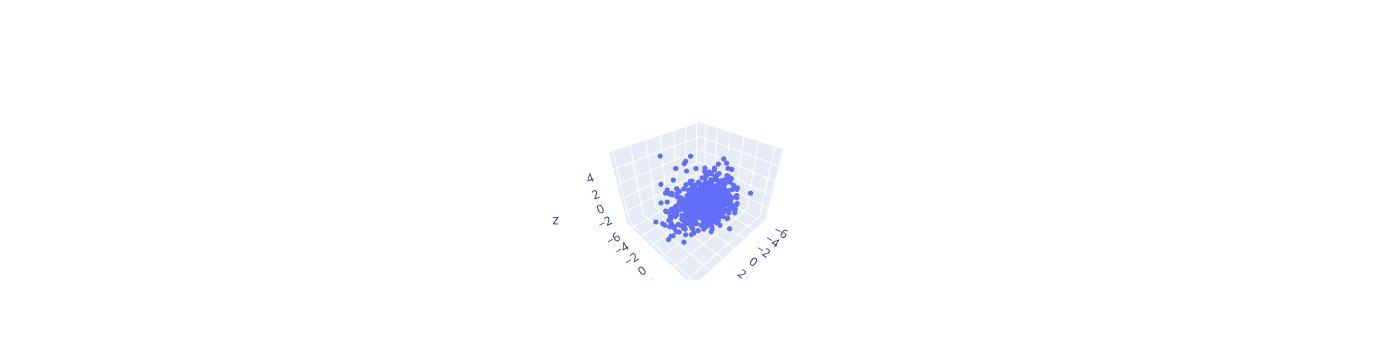

In [11]:
fig=go.Figure(data=[go.Scatter3d(x=reduced[:,0],y=reduced[:,1],z=reduced[:,2],
                                mode='markers',
                                marker=dict(
                                    size=3
                                ))])
fig.show()

This is actually not that helpful in this dataset, but it demonstrates the capability.